# Homework 4
- **Joshua Dunne**
- **MATH765**
- **Spring 2026**

## Question 1
- Find the general solution
- Describe the behavior of the solution as $t \to \infty$.
- Draw a sketch without technology
- Use technology to draw a phase portrait

### Part a
$$\mathbf{x}' = \begin{bmatrix}3 && -4 \\ 1 && -1\end{bmatrix}\mathbf{x}$$

> I'm trying to make a point to flip between using technology and not using technology. I will try to be honest and do these on pen and paper first, then copy the cliff notes of the work across so that I can recreate it later for presentations

#### Finding the general solution
We're going to solve the characteristic and see where we get, so
$$\det\left(\begin{bmatrix}3 && -4 \\ 1 && -1\end{bmatrix}-\lambda\mathbf{I}_2\right) = 0$$
$$0=\lambda^2-3\lambda+\lambda-3+4=\lambda^2-2\lambda+1=(\lambda-1)^2$$
And we're away, we have a repeated root, so, we'll have to find a generalized eigenvector, but first, let's find the eigenvector
$$\begin{align*}
\mathbf{A}-\lambda\mathbf{I}_2&=\begin{bmatrix}2 && -4\\1 && -2\end{bmatrix}\\
2v_1-4v_2&=0\\
v_1&=2v_2
\end{align*}$$
Let's let $v_2=1$, so we have $\mathbf{v} = \begin{bmatrix}2 \\ 1\end{bmatrix}$. From here we can solve the corresponding augmented system
$$\begin{align*}
(\mathbf{A}-\lambda\mathbf{I}_2)\mathbf{w}&=\mathbf{v}\\
\begin{bmatrix}2 && -4\\1 && -2\end{bmatrix}\begin{bmatrix}w_1 \\ w_2\end{bmatrix}&=\begin{bmatrix}2 \\ 1\end{bmatrix}\\
2w_1-4w_2&=2\\
w_1-2w_2&=1
\end{align*}$$
Let's let $w_2=0$, so we have $\mathbf{w} = \begin{bmatrix}1 \\ 0\end{bmatrix}$.

Our general solution will then be of the form
$$\mathbf{x}(t)=c_1e^t\begin{bmatrix}2 \\ 1\end{bmatrix}+c_2e^t\left(\begin{bmatrix}1 \\ 0\end{bmatrix}+t\begin{bmatrix}2 \\ 1\end{bmatrix}\right)$$

#### Describe the behavior as $t\rightarrow \infty$
As $t\rightarrow \infty$, we have that $e^t\rightarrow \infty$. Neither term grows at a faster rate, that is
$$\lim_{t\rightarrow \infty}c_1e^t\mathbf{v} = \infty = \lim_{t\rightarrow \infty}c_2e^t\left(t\mathbf{v}+\mathbf{w}\right)$$
$$\frac{\lim_{t\rightarrow \infty}c_1e^t\mathbf{v}}{\lim_{t\rightarrow \infty}c_2e^t\left(t\mathbf{v}+\mathbf{w}\right)} = \frac{c_1}{c_2}$$
So, there's nothing asymptotically dominant, and the solution will grow without bound as $t\rightarrow \infty$.

#### Draw without technology
I'm going to recreate this here, this is a degenerate node, so, I will plot the nullclines, the eigendirection

Let $x'=0$, so $3x-4y=0$, so $y=\frac{3}{4}x$ 

Let $y'=0$, so $x-y=0$, so $y=x$

And our eigendirection is $y=\frac{1}{2}x$

We know this is degenerate, so, we just need to sample a point above and below the eigendirection, so let's sample $(2, 2)$ and $(2, 0)$
$$\begin{align*}
\mathbf{x}'(2, 2) &= \begin{bmatrix}3 && -4 \\ 1 && -1\end{bmatrix}\begin{bmatrix}2 \\ 2\end{bmatrix} = \begin{bmatrix}-2 \\ 0\end{bmatrix}\\
\mathbf{x}'(2, 0) &= \begin{bmatrix}3 && -4 \\ 1 && -1\end{bmatrix}\begin{bmatrix}2 \\ 0\end{bmatrix} = \begin{bmatrix}6 \\ 2\end{bmatrix}
\end{align*}$$

From this we could make our graph, there's nothing weird going on here, just a degenerate node, all the lines above go down and left, all the nodes below go up and right

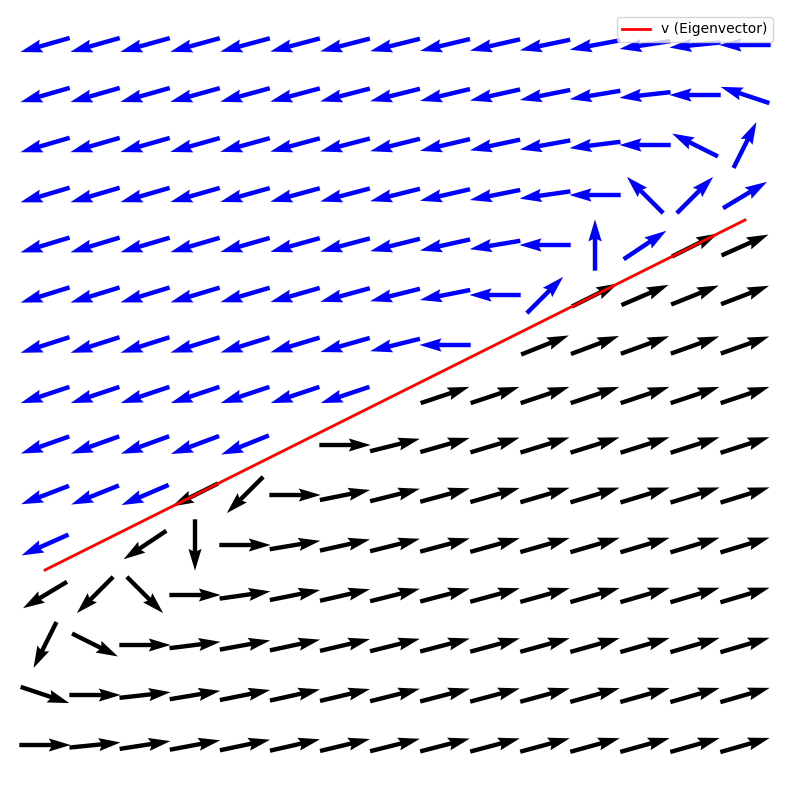

In [7]:
import numpy as np
import matplotlib.pyplot as plt

widthAndHeight = 2
samples = 15
x, y = np.meshgrid(
    np.linspace(-widthAndHeight, widthAndHeight, samples),
    np.linspace(-widthAndHeight, widthAndHeight, samples))

u = 3*x - 4*y
v = x - y

magnitude = np.sqrt(u**2 + v**2) + 1e-10
uNorm, vNorm = u/magnitude, v/magnitude

above = y > 0.5 * x
below = y < 0.5 * x

plt.figure(figsize=(10, 10))

s_factor = samples / (widthAndHeight / 2)

plt.quiver(x[above], y[above], uNorm[above], vNorm[above], 
           pivot='mid', angles='xy', color='blue', scale=s_factor)

plt.quiver(x[below], y[below], uNorm[below], vNorm[below], 
           pivot='mid', angles='xy', color='black', scale=s_factor)

xVals = np.linspace(-widthAndHeight, widthAndHeight, 100)
plt.plot(xVals, 0.5 * xVals, color='red', lw=2, label='v (Eigenvector)')

plt.gca().set_aspect('equal')
plt.axis('off')
plt.legend()
plt.show()

> This is just doing as I would by hand, we're simply mapping x and y to a direction for each point and plotting, all I'm trying to do is faithfully recreate the methodology I'd have used by hand to draw this in here, it is **not** using any fancy software to do it for me

#### Draw with technology
Now we can generate the phase portrait as we usually would, I'm going to borrow from the code above, and only make slight changes, we are now calculating the value at each individual point, so, the only changes we really need to make are to the ways I've calculate the $u$ & $v$

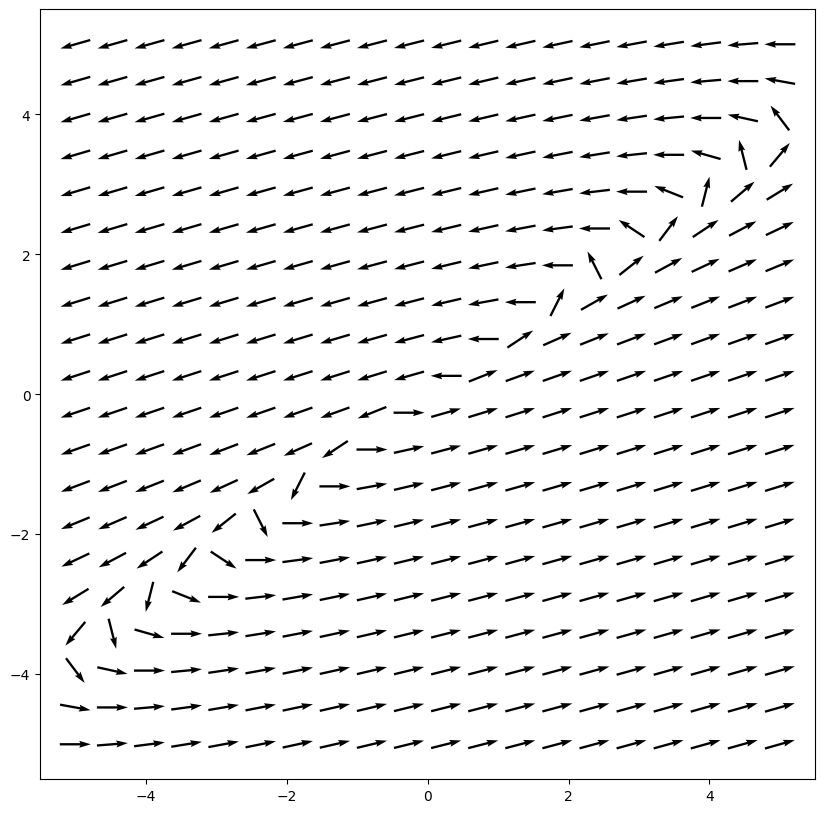

In [8]:
import numpy as np
import matplotlib.pyplot as plt

widthAndHeight = 5
samples = 20
x, y = np.meshgrid(
    np.linspace(-widthAndHeight, widthAndHeight, samples),
    np.linspace(-widthAndHeight, widthAndHeight, samples))

u = 3*x - 4*y
v = 1*x - 1*y

magnitude = np.sqrt(u**2 + v**2) + 1e-10
uNorm = u/magnitude
vNorm = v/magnitude

plt.figure(figsize=(10, 10))
plt.quiver(x, y, uNorm, vNorm, pivot='mid', angles='xy', scale=25)

plt.show()

### Part B
#### Finding the general solution
We can tell off the bat this is singular, everything is a scaled copy, and $\det\left(\mathbf{A}\right)=0$. This gives us that $\lambda=0$ and that $\mathbf{A}-\lambda=\mathbf{A}$.
$$\mathbf{x}'=\begin{bmatrix}4 & -2 \\ 8 & -4\end{bmatrix}\mathbf{x}$$
$$
\begin{align*}
\det\left(\mathbf{A}\right)&=0\\
(4-\lambda)(-4-\lambda)+16=\lambda^2&=0\\
\lambda&=0
\end{align*}$$
Likewise, we can just plug and chug to get $\mathbf{v}$ and $\mathbf{w}$
$$\begin{align*}
\mathbf{A}\mathbf{v}&=\mathbf{0}\\
\begin{bmatrix}4 && -2 \\ 8 && -4\end{bmatrix}\begin{bmatrix}v_1 \\ v_2\end{bmatrix}&=\mathbf{0}\\
4v_1-2v_2&=0\\
v_1&=\frac{1}{2}v_2\\
\mathbf{A}\mathbf{w}&=\mathbf{v}\\
\begin{bmatrix}4 && -2 \\ 8 && -4\end{bmatrix}\begin{bmatrix}w_1 \\ w_2\end{bmatrix}&=\begin{bmatrix}\frac{1}{2}v_2 \\ v_2\end{bmatrix}\\
4w_1-2w_2&=\frac{1}{2}v_2\\
8w_1-4w_2&=v_2
\end{align*}$$


If we let $v_2=2$, then we have $v_1=1$, and $w_1=0$, $w_2=-\frac{1}{4}$, so $\mathbf{v} = \begin{bmatrix}1 \\ 2\end{bmatrix}$ and $\mathbf{w} = \begin{bmatrix}0 \\ -\frac{1}{2}\end{bmatrix}$ this then gives us the general solution
$$\mathbf{x}(t)=c_1\begin{bmatrix}1 \\ 2\end{bmatrix}+c_2\left(\begin{bmatrix}0 \\ -\frac{1}{2}\end{bmatrix}+t\begin{bmatrix}1 \\ 2\end{bmatrix}\right)$$

### Describing end behavior as $t\rightarrow \infty$
As $t\rightarrow \infty$, we have that $t\rightarrow \infty$, and the $t\mathbf{v}$ term dominates the $\mathbf{w}$ term, so we have that
$$\lim_{t\rightarrow \infty}c_1\mathbf{v} = \infty = \lim_{t\rightarrow \infty}c_2t\mathbf{v}$$
$$\frac{\lim_{t\rightarrow \infty}c_1\mathbf{v}}{\lim_{t\rightarrow \infty}c_2t\mathbf{v}} = 0$$
So, the $t\mathbf{v}$ term dominates the $\mathbf{w}$ term, and the solution will grow without bound as $t\rightarrow \infty$.

#### Plotting by hand
We can use the code from above, although, I did just forget to save, and I'm now recreating this from memory, so, we'll see how well I do, but, the idea is to plot the nullclines and the eigendirections, so, let's start with the nullclines


Let $x'=0$, so $y=\frac{1}{2}x$. 


Let $y'=0$, so $y=\frac{1}{2}x$. 


And our eigendirection is $y=\frac{1}{2}x$

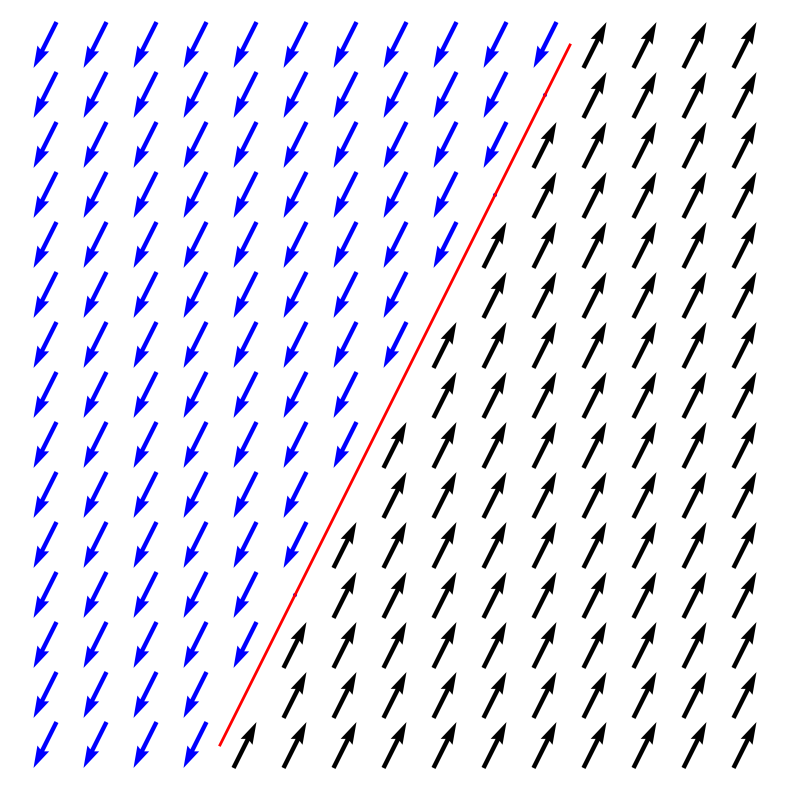

In [9]:
import numpy as np
import matplotlib.pyplot as plt

w, s = 2, 15
x, y = np.meshgrid(np.linspace(-w, w, s), np.linspace(-w, w, s))

# System 1b: The singular matrix case
u = 4*x - 2*y
v = 8*x - 4*y

mag = np.sqrt(u**2 + v**2) + 1e-10
uN, vN = u/mag, v/mag

# Your specific mask for 1b
above = y > 2 * x
below = y < 2 * x

plt.figure(figsize=(10, 10))

# Using your manual scale fix (w/2) and the inward/outward logic
plt.quiver(x[above], y[above], uN[above], vN[above], 
           pivot='mid', angles='xy', color='blue', scale=s/(w/2))

plt.quiver(x[below], y[below], uN[below], vN[below], 
           pivot='mid', angles='xy', color='black', scale=s/(w/2))

# The "Dead Line" equilibrium for 1b
t = np.linspace(-w/2, w/2, 100)
plt.plot(t, 2 * t, color='red', lw=2)

plt.gca().set_aspect('equal')
plt.axis('off')
plt.show()

### Plot with technology

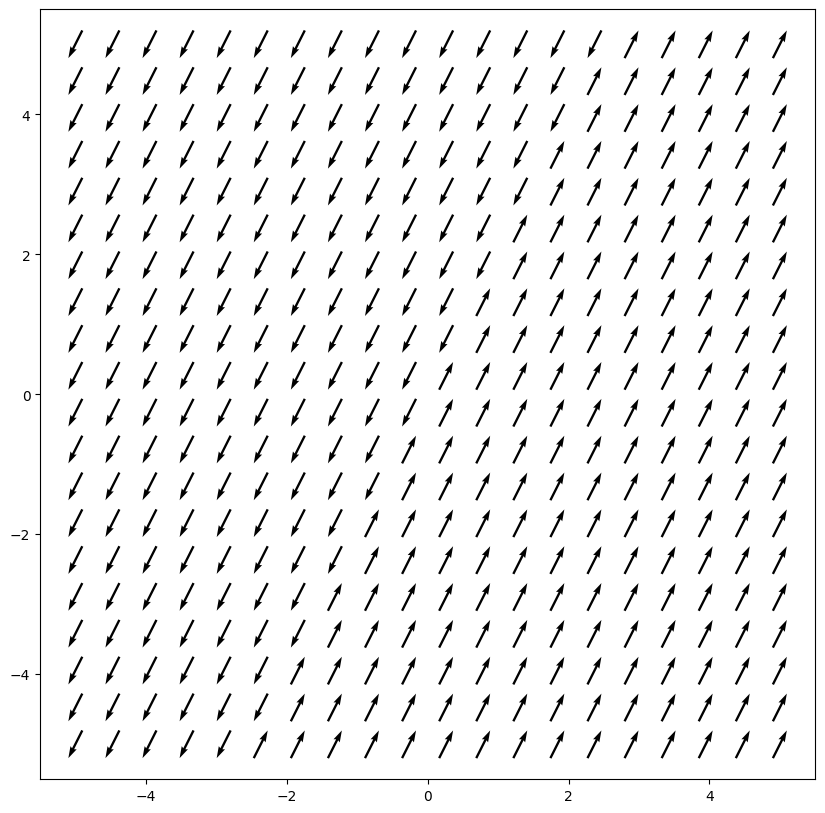

In [12]:
import numpy as np
import matplotlib.pyplot as plt

widthAndHeight = 5
samples = 20
x, y = np.meshgrid(
    np.linspace(-widthAndHeight, widthAndHeight, samples),
    np.linspace(-widthAndHeight, widthAndHeight, samples))

u = 4*x - 2*y
v = 8*x - 4*y

magnitude = np.sqrt(u**2 + v**2) + 1e-10
uNorm = u/magnitude
vNorm = v/magnitude

plt.figure(figsize=(10, 10))
plt.quiver(x, y, uNorm, vNorm, pivot='mid', angles='xy', scale=25)

plt.show()